In [1]:
print(5_5)

55


In [2]:
import sys
sys.path.append('../../datasets')
#from spark_utils import *
import getpass
import pathlib
import os
import io
from tqdm import tqdm
from optuna.samplers import TPESampler
#import datadicts as dd
import pathlib
import sys
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn
import catboost as cb
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn import metrics
import optuna
import shap
#from optuna.samplers import TPESampler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, precision_recall_curve, roc_curve
import warnings
warnings.filterwarnings('ignore')

import pickle

from sklearn.preprocessing import LabelEncoder

/opt/user-venvs/python3.8/lib64/python3.8/site-packages/shap/utils/_clustering.py:35: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _pt_shuffle_rec(i, indexes, index_mask, partition_tree, M, pos):
/opt/user-venvs/python3.8/lib64/python3.8/site-packages/shap/utils/_clustering.py:54: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def delta_minimization_order(al

In [3]:
import logging
logging.basicConfig(level=logging.INFO, format='[%(asctime)s %(levelname)s - %(message)s]')

def normalize_column_names(data):
    logging.info("Приведение колонок к нижнему регистру")
    rename_map = {col: col.lower() for col in data.columns if col != col.lower()}
    return data.rename(columns=rename_map)

def remove_bad_columns(data):
    logging.info("Удаление плохик признаков")
    bad_columns = []
    bad_columns += list(filter(lambda x: x[-3:] in ["_id", "_dk"], data.columns)) 
    bad_columns += list(filter(lambda x: x[:4] in ["act"], data.columns))
    bad_columns += [col for col in data.columns if '_oi_' in col] 
    bad_columns += [
          "ctl_loading"                    
        , "row_upd_dttm"                   
        , "prl_tax_payer_inn"              
        , "prl_agrmnt_nbr"                 
        , "dep_payroll_bitmask_l12m_cd"    
        , "dep_social_bitmask_l12m_cd"     
        , "crd_lst_agrmnt_vsp_cd"          
        , "crd_lst_agrmnt_osb_cd"         
        , "prd_lst_prod_osb_cd"           
        , 'birth_dt'                       
        , 'sd_age_mnth_comp_nv'                     
        , 'sd_age_yrs_comp_nv'
        , 'data_type'
        , 'type'
        , 'sd_age_yrs_comp_nv'
        , 'crd_lst_agrmnt_tb_cd'
        , 'prl_tbholding_id'
        , 'dep_lst_payroll_agrmnt_id'
        , 'dep_acct_1st_division_dk'
        , 'dep_acct_lst_division_dk'
        , 'dep_acct_max_bal_division_dk'
        , 'prd_1st_prod_division_dk'
        , 'prd_lst_prod_division_dk'
        , 'seg_main_card_dwh_id'
        , 'tp_lst_division_dk'
        , 'crd_cc_lst_plastic_type_id'
        , 'crd_dc_lst_plastic_type_id'
        , 'prd_lst_prod_vsp_cd'
        , 'seg_crd_pos_cat_group'
        , 'seg_crm_segment_cd'
        , 'seg_client_cx_segment_cd'
        , 'seg_client_cx_criteria'
        , 'prl_tax_payer_inn'
        , 'prd_1st_prod_division_dk'
        , 'tp_lst_tb_cd'
        , 'tp_lst_kind_cd'
        , 'sd_dead_nflag'
    ]
    bad_columns = list(set(bad_columns))
    bad_columns = [col for col in bad_columns if col in data.columns]
    logging.info(f"Удалено {len(bad_columns)} колонок: {bad_columns}")
    return data.drop(columns=bad_columns, errors="coerce")

def process_date_columns(data, report_col):
    logging.info("Преобразование datetime колонок в 'дни до report_dt'")
    if report_col in data.columns:
        data[report_col] = pd.to_datetime(data[report_col].astype(str), errors="coerce")
    date_cols = [col for col in data.columns if "_dt" in col != report_col]
    for col in tqdm(date_cols, desc="Обработка дат"):
        data[col] = pd.to_datetime(data[col].astype(str), errors="coerce")
        data[col] = (data[report_col] - data[col]).dt.days
    return data.drop(columns=[report_col], errors="ignore")
    # return data

def fill_missing_values(data):
    EXCLUDED_COLS = ["report_dt"]
    logging.info("Заполнение пропусков")
    fill_config = {
        "flg":               {"fill": -1,   "type": "int32"},
        "_qty":              {"fill": -999999},
        "_pct":              {"fill": -999999},
        "_days":             {"fill": -999999},
        "_num":              {"fill": -999999},
        "_amt":              {"fill": -999999},
        "_prc":              {"fill": -999999},
        "_rate":             {"fill": -999999,   "type": "float64"},
        "_frac":             {"fill": -999999,   "type": "float64"},
        "_nflag":            {"fill": -999999,   "type": "float64"},
        "_dt":               {"fill": -999999,   "type": "float64"},
        "float64":           {"fill": -999999},
        "int32":             {"fill": -999999},
        "object":            {"fill": 'UNKNOWN'}
    }
    
    for col in tqdm(data.columns, desc="Заполнение пропусков"):
        if col in EXCLUDED_COLS:
            continue
        col_handled = False
        
        for pattern, rule in fill_config.items():
            if pattern in col:
                fill_val = rule["fill"]
                dtype = rule.get("type", None)
                data[col] = data[col].fillna(fill_val)
                if dtype:
                    data[col] = data[col].astype(dtype)
                col_handled = True
                break
                
        if not col_handled:
            col_type = str(data[col].dtype)
            if col_type in fill_config:
                fill_val = fill_config[col_type]["fill"]
                dtype = fill_config[col_type].get("type", None)
                data[col] = data[col].fillna(fill_val)
                if dtype:
                    data[col] = data[col].astype(dtype)
                    
    return data

def preprocess(data):
    logging.info("Старт предобработки")
    data = normalize_column_names(data)
    data = remove_bad_columns(data)
    data = process_date_columns(data, report_col="report_dt")
    data = fill_missing_values(data)
    cat_features = data.select_dtypes(include="object").columns.tolist()
    logging.info(f"предобработка завершена. Число признаков: {data.shape[1]-1}")
    return data, cat_features

def prepare_dataset(train_df):
    logging.info("=== Запуск подготовки датасетов ===")
    train_df, cat_features = preprocess(train_df)
    logging.info(f"=== Подготовка завершена. Число признаков: {train_df.shape[1]-1} ===")
    return train_df, cat_features

In [4]:
def remove_corelated_features(df, threshold = 0.95, method = 'pearson'):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    non_numeric_cols = df.columns.difference(numeric_cols).tolist()
    
    if not numeric_cols:
        return df
    
    corr_matrix = df[numeric_cols].corr(method = method).abs()
    parent = {}
    def find(u):
        while parent[u] != u:
            parent[u] = parent[parent[u]]
            u = parent[u]
        return u
    
    def union(u, v):
        root_u = find(u)
        root_v = find(v)
        if root_u != root_v:
            parent[root_v] = root_u
    
    for col in numeric_cols:
        parent[col] = col
        
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > threshold:
                col_i = corr_matrix.columns[i]
                col_j = corr_matrix.columns[j]
                union(col_i, col_j)
                
    groups = {}
    for col in numeric_cols:
        root = find(col)
        if root not in groups:
            groups[root] = []
        groups[root].append(col)
    
    selected = []
    for group in groups.values():
        best = max(group, key = lambda x: corr_matrix[x].sum())
        selected.append(best)
    
    result_cols = non_numeric_cols + selected
    
    result_cols = list(dict.fromkeys(result_cols))
    
    return result_cols

In [5]:
def cat_fi(model):
    cat_fi = pd.Series(
    data=model.feature_importances_,
    index=model.feature_names_,
    )
    fi = pd.DataFrame({"catboost_importance": cat_fi}).reset_index().sort_values(by = "catboost_importance", ascending = False)
    fi = fi.reset_index(drop = True)
    fi["desc"] = fi["index"].map(dd.FT_CLIENT_AGGR_MNTH)
    return fi

In [6]:
!hdfs dfs -get hdfs://arnsdpsbx/user/team/team_ss/bpm_agent_py_model_paid_new_all_features_fix_types_train_model

Picked up JAVA_TOOL_OPTIONS: -XX:ThreadStackSize=4096 -XX:VMThreadStackSize=4096


In [7]:
df = pd.read_parquet('bpm_agent_py_model_paid_new_all_features_fix_types_train_model')

In [8]:
train_df, cat_features = prepare_dataset(df)

[2026-03-11 05:44:30,230 INFO - === Запуск подготовки датасетов ===]
[2026-03-11 05:44:30,231 INFO - Старт предобработки]
[2026-03-11 05:44:30,231 INFO - Приведение колонок к нижнему регистру]
[2026-03-11 05:44:32,769 INFO - Удаление плохик признаков]
[2026-03-11 05:44:32,774 INFO - Удалено 51 колонок: ['pnl_oi_cc_amt', 'prd_lst_prod_division_dk', 'dep_social_bitmask_l12m_cd', 'dep_payroll_bitmask_l12m_cd', 'crd_cc_lst_plastic_type_id', 'tp_lst_tb_cd', 'seg_client_cx_segment_cd', 'dep_acct_max_bal_division_dk', 'crd_lst_agrmnt_osb_cd', 'prl_subholding_id', 'pnl_oi_td_amt', 'prd_lst_prod_vsp_cd', 'pnl_oi_othr_amt', 'actual_epk_id', 'pnl_oi_dc_amt', 'seg_client_cx_criteria', 'pnl_oi_cc_amt_12m', 'dep_lst_payroll_agrmnt_id', 'pnl_oi_td_amt_12m', 'sd_age_mnth_comp_nv', 'prl_holding_id', 'row_upd_dttm', 'seg_main_card_dwh_id', 'sd_dead_nflag', 'tp_lst_division_dk', 'pnl_oi_ca_amt_12m', 'pnl_oi_othr_amt_12m', 'prl_tbholding_id', 'pnl_oi_dc_amt_12m', 'pnl_oi_total_amt', 'prl_agrmnt_nbr', 'crd

In [9]:
train_df.to_parquet('prep_data_new.parquet')

In [10]:
cols = list(train_df.columns)
feats = remove_corelated_features(train_df[cols], threshold=0.95)

In [11]:
train_df[feats].shape

(91854, 1790)

In [12]:
final_df = train_df[feats]

In [16]:
final_df.to_parquet('final_new.parquet')

In [17]:
final_df = pd.read_parquet('final_new.parquet')

# Catboost

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
pd.set_option('Display.max_columns', None)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
import sys
import gc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance 
from catboost import CatBoostClassifier
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from sklearn.model_selection import train_test_split
import catboost as ctb
from typing import Union
import optuna 
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, precision_recall_curve, roc_curve, classification_report
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from catboost import Pool

In [382]:
def get_pool(target_column = 'target', features = None):
    features = train.columns.tolist() if features is None else features
    categorical_columns = train[features].select_dtypes('object').columns.tolist()
    
    train_pool = ctb.Pool(data = train[features].drop(target_column, axis = 1, errors = 'ignore'), label = train[target_column], cat_features = categorical_columns)
    val_pool  = ctb.Pool(data = val[features].drop(target_column, axis = 1, errors = 'ignore'), label = val[target_column],  cat_features = categorical_columns)
    test_pool  = ctb.Pool(data = test[features].drop(target_column, axis = 1, errors = 'ignore'), label = test[target_column],  cat_features = categorical_columns)
    
    return train_pool, val_pool, test_pool

def show_importances(model : Union[ctb.CatBoostClassifier, None], num : int = None) -> pd.DataFrame:
    importances = model.get_feature_importance(prettified=True)
    importances['Фичи'] = importances['Feature Id'].apply(lambda x: feature_names.get(x))
    if num:
        return importances.head(num)
    return importances.head(min(len(importances), 30))

In [384]:
with open ('features_dict.pkl', 'rb') as f:
    feature_names = pickle.load(f)
    
from catboost import Pool

In [385]:
final_df['target'].value_counts()

target
0.0    61236
1.0    30618
Name: count, dtype: int64

In [386]:
x = final_df.drop(columns=['target'])
y = final_df['target']

In [387]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.25, random_state = 0)

In [388]:
text_columns = x_train.select_dtypes(include=['object']).columns.tolist()

# First iter

In [ ]:
'srv_mb_full_qty_sum_12m', 'dep_mnth_payroll_min_qty_sum_3m', 'dep_acct_tot_qty_sum_3m', 'tp_active_kind_cd', 'tp_best_kind_ever_cd', 'prd_lst_prod_tb_cd', 'seg_premier_cd', 'srv_thanks_mnth_qty_sum_12m', 'crd_dc_mnth_snc_open_qty_sum_3m'

In [389]:
x_train = x_train.drop(columns=['srv_mb_full_qty_sum_12m', 'dep_mnth_payroll_min_qty_sum_3m', 'dep_acct_tot_qty_sum_3m', 'tp_active_kind_cd', 'tp_best_kind_ever_cd', 'prd_lst_prod_tb_cd', 'seg_premier_cd', 'srv_thanks_mnth_qty_sum_12m', 'crd_dc_mnth_snc_open_qty_sum_3m'])
x_val = x_val.drop(columns=['srv_mb_full_qty_sum_12m', 'dep_mnth_payroll_min_qty_sum_3m', 'dep_acct_tot_qty_sum_3m', 'tp_active_kind_cd', 'tp_best_kind_ever_cd', 'prd_lst_prod_tb_cd', 'seg_premier_cd', 'srv_thanks_mnth_qty_sum_12m', 'crd_dc_mnth_snc_open_qty_sum_3m'])
x_test = x_test.drop(columns=['srv_mb_full_qty_sum_12m', 'dep_mnth_payroll_min_qty_sum_3m', 'dep_acct_tot_qty_sum_3m', 'tp_active_kind_cd', 'tp_best_kind_ever_cd', 'prd_lst_prod_tb_cd', 'seg_premier_cd', 'srv_thanks_mnth_qty_sum_12m', 'crd_dc_mnth_snc_open_qty_sum_3m'])

In [390]:
text_columns = x_train.select_dtypes(include=['object']).columns.tolist()

In [391]:
model = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=5, cat_features=text_columns, random_seed=0)
model.fit(x_train, y_train, eval_set = (x_val, y_val), verbose=100, plot=True, early_stopping_rounds = 100)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6589480	test: 0.6592346	best: 0.6592346 (0)	total: 142ms	remaining: 2m 21s
100:	learn: 0.5070853	test: 0.5155350	best: 0.5155350 (100)	total: 12.1s	remaining: 1m 47s
200:	learn: 0.4935431	test: 0.5130911	best: 0.5110976 (144)	total: 23.7s	remaining: 1m 34s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5110975507
bestIteration = 144

Shrink model to first 145 iterations.


In [392]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(x_test)[:, 1])}")

TRAIN : 0.7544378408319272
VAL : 0.7143215661613564
TEST : 0.7100087325194129


In [393]:
print(f"TRAIN : {f1_score(y_train, model.predict(x_train))}")
print(f"VAL : {f1_score(y_val, model.predict(x_val))}")
print(f"TEST : {f1_score(y_test, model.predict(x_test))}")

TRAIN : 0.38615068445435236
VAL : 0.3196746950265874
TEST : 0.3089940457536822


In [394]:
print(classification_report(y_test, model.predict(x_test)))

              precision    recall  f1-score   support

         0.0       0.69      0.84      0.76     12285
         1.0       0.42      0.24      0.31      6086

    accuracy                           0.64     18371
   macro avg       0.56      0.54      0.53     18371
weighted avg       0.60      0.64      0.61     18371



In [395]:
show_importances(model)

,Feature Id,Importances,Фичи
0,srv_pmt_budg_qty_sum_12m,9.269997,None
1,srv_mb_econ_qty_sum_6m,6.955947,None
2,crd_tot_act_qty_sum_6m,6.883924,None
3,crd_dc_open_qty_sum_9m,5.149803,None
4,crd_otf_total_qty_sum_12m,4.634509,None
5,crd_dc_act_spend_qty_sum_12m,4.474864,None
6,crd_cc_mnth_snc_issue_qty_sum_3m,4.010689,None
7,srv_pmt_budg_amt_sum_12m,3.784244,None
8,dep_inf_othr_qty_sum_12m,3.689295,None
9,crd_otf_total_qty_12m,3.657410,None


In [396]:
importances = model.get_feature_importance(prettified=True)

In [401]:
a = importances.loc[importances['Importances'] > 0.03, 'Feature Id'].tolist()

In [402]:
len(a)

102

# Second iter

In [403]:
x_train_new = x_train[a]
x_val_new = x_val[a]
x_test_new = x_test[a]

In [404]:
text_columns = x_train_new.select_dtypes(include=['object']).columns.tolist()

In [405]:
model = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=5, cat_features=text_columns, random_seed=0)
model.fit(x_train_new, y_train, eval_set = (x_val_new, y_val), verbose=100, plot=True, early_stopping_rounds = 100)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6528328	test: 0.6530042	best: 0.6530042 (0)	total: 27.4ms	remaining: 27.4s
100:	learn: 0.5016134	test: 0.5088077	best: 0.5088077 (100)	total: 2.05s	remaining: 18.2s
200:	learn: 0.4914029	test: 0.5077954	best: 0.5068931 (128)	total: 4.07s	remaining: 16.2s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5068930613
bestIteration = 128

Shrink model to first 129 iterations.


In [406]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(x_train_new)[:, 1])}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(x_val_new)[:, 1])}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(x_test_new)[:, 1])}")

TRAIN : 0.7491825414212255
VAL : 0.7207157606551557
TEST : 0.7177256234108024


In [407]:
print(f"TRAIN : {f1_score(y_train, model.predict(x_train_new))}")
print(f"VAL : {f1_score(y_val, model.predict(x_val_new))}")
print(f"TEST : {f1_score(y_test, model.predict(x_test_new))}")

TRAIN : 0.382555417871403
VAL : 0.3373816385343763
TEST : 0.3325020781379884


In [408]:
print(classification_report(y_test, model.predict(x_test_new)))

              precision    recall  f1-score   support

         0.0       0.70      0.84      0.76     12285
         1.0       0.45      0.26      0.33      6086

    accuracy                           0.65     18371
   macro avg       0.57      0.55      0.55     18371
weighted avg       0.62      0.65      0.62     18371



# Third iter

In [410]:
train = pd.concat([x_train_new, y_train], axis=1)
val = pd.concat([x_val_new, y_val], axis=1)
test = pd.concat([x_test_new, y_test], axis=1)

In [411]:
def get_pool(target_column = 'target', features = None):
    features = train.columns.tolist() if features is None else features
    text_columns = train[features].select_dtypes('object').columns.tolist()
    
    train_pool = ctb.Pool(data = train[features].drop(target_column, axis = 1, errors = 'ignore'), label = train[target_column], cat_features = text_columns)
    val_pool  = ctb.Pool(data = val[features].drop(target_column, axis = 1, errors = 'ignore'), label = val[target_column],  cat_features = text_columns)
    test_pool  = ctb.Pool(data = test[features].drop(target_column, axis = 1, errors = 'ignore'), label = test[target_column],  cat_features = text_columns)
    
    return train_pool, val_pool, test_pool

In [412]:
def simple_train(target_column = 'target', features = None, model_params = None):
    features = train.columns.tolist() if features is None else features
    text_columns = train[features].select_dtypes('object').columns.tolist()
    
    train_pool = ctb.Pool(data = train[features].drop(target_column, axis = 1, errors = 'ignore'), label = train[target_column], cat_features = text_columns)
    val_pool  = ctb.Pool(data = val[features].drop(target_column, axis = 1, errors = 'ignore'), label = val[target_column],  cat_features = text_columns)
    test_pool  = ctb.Pool(data = test[features].drop(target_column, axis = 1, errors = 'ignore'), label = test[target_column],  cat_features = text_columns)
    

    model = ctb.CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=5, cat_features=text_columns, random_seed=0)
    
        
    model.fit(train_pool, eval_set = val_pool, verbose=100, plot=True, early_stopping_rounds = 100)

    
    
    train_preds = model.predict(train_pool)
    train_probas = model.predict_proba(train_pool)[:, 1]
    
    val_preds = model.predict(val_pool)
    val_probas = model.predict_proba(val_pool)[:, 1]
    
    
    test_preds = model.predict(test_pool)
    test_probas = model.predict_proba(test_pool)[:, 1]
    
    
    
    return train_preds, train_probas, val_preds, val_probas, test_preds, test_probas, model

In [413]:
train_pool, val_pool, test_pool = get_pool('target')

In [414]:
model = ctb.CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=5, verbose=0, random_seed=0, early_stopping_rounds=100)

summary = model.select_features(train_pool, eval_set = val_pool,
                                features_for_select = train.drop('target', axis = 1, errors = 'ignore').columns.tolist(), 
                                steps = 5, 
                                verbose = 0,
                                num_features_to_select=47)


best_features = summary['selected_features_names']

Step #1 out of 5
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5066395708
bestIteration = 166

Shrink model to first 167 iterations.
Feature #40 eliminated
Feature #57 eliminated
Feature #35 eliminated
Feature #98 eliminated
Feature #88 eliminated
Feature #70 eliminated
Feature #87 eliminated
Feature #95 eliminated
Feature #50 eliminated
Feature #64 eliminated
Feature #99 eliminated
Feature #85 eliminated
Feature #81 eliminated
Feature #49 eliminated
Feature #72 eliminated
Step #2 out of 5
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5062611705
bestIteration = 173

Shrink model to first 174 iterations.
Feature #61 eliminated
Feature #79 eliminated
Feature #43 eliminated
Feature #100 eliminated
Feature #75 eliminated
Feature #66 eliminated
Feature #51 eliminated
Feature #15 eliminated
Feature #13 eliminated
Feature #77 eliminated
Feature #90 eliminated
Feature #92 eliminated
Step #3 out of 5
Stopped by overfitting detector  (100 iterations 

In [415]:
train_preds, train_probas, val_preds, val_probas, test_preds, test_probas, model = simple_train('target', best_features)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6573334	test: 0.6578658	best: 0.6578658 (0)	total: 20.4ms	remaining: 20.4s
100:	learn: 0.5015607	test: 0.5078098	best: 0.5078098 (100)	total: 1.81s	remaining: 16.2s
200:	learn: 0.4912196	test: 0.5043481	best: 0.5039286 (179)	total: 3.56s	remaining: 14.2s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5039285661
bestIteration = 179

Shrink model to first 180 iterations.


In [416]:
target_column = 'target' 
RANDOM_SEED = 0

train_roc_auc = []
val_roc_auc = []
test_roc_auc = []


train_f1 = []
val_f1 = []
test_f1 = []


importances  = show_importances(model, -1)['Feature Id'].tolist()

xticks = range(1, len(best_features), 3)

for num_features in tqdm(xticks):
    used_features = importances[: num_features]
    
    
    train_preds, train_probas, val_preds, val_probas, test_preds, test_probas, model_temp = simple_train(target_column, used_features)

    train_f1.append(f1_score(train[target_column], train_preds))
    val_f1.append(f1_score(val[target_column], val_preds))
    test_f1.append(f1_score(test[target_column], test_preds))


    train_roc_auc.append(roc_auc_score(train[target_column], train_probas))
    val_roc_auc.append(roc_auc_score(val[target_column], val_probas))
    test_roc_auc.append(roc_auc_score(test[target_column], test_probas))

  0%|          | 0/16 [00:00<?, ?it/s]

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6692219	test: 0.6695569	best: 0.6695569 (0)	total: 5.29ms	remaining: 5.28s
100:	learn: 0.5643722	test: 0.5663772	best: 0.5663772 (100)	total: 512ms	remaining: 4.55s
200:	learn: 0.5601935	test: 0.5628581	best: 0.5628581 (200)	total: 1.04s	remaining: 4.13s
300:	learn: 0.5578252	test: 0.5611320	best: 0.5611306 (299)	total: 1.59s	remaining: 3.69s
400:	learn: 0.5569135	test: 0.5607719	best: 0.5607719 (400)	total: 2.1s	remaining: 3.14s
500:	learn: 0.5564407	test: 0.5607528	best: 0.5607148 (487)	total: 2.64s	remaining: 2.63s
600:	learn: 0.5560890	test: 0.5606909	best: 0.5606589 (585)	total: 3.19s	remaining: 2.12s
700:	learn: 0.5558602	test: 0.5606209	best: 0.5606014 (689)	total: 3.67s	remaining: 1.57s


  6%|▋         | 1/16 [00:04<01:05,  4.36s/it]

Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5606014414
bestIteration = 689

Shrink model to first 690 iterations.


...

Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5046802204
bestIteration = 185

Shrink model to first 186 iterations.


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6532520	test: 0.6536992	best: 0.6536992 (0)	total: 35.8ms	remaining: 35.8s
100:	learn: 0.5009914	test: 0.5076739	best: 0.5076739 (100)	total: 1.75s	remaining: 15.6s
200:	learn: 0.4907577	test: 0.5044060	best: 0.5039786 (181)	total: 3.44s	remaining: 13.7s


100%|██████████| 16/16 [00:52<00:00,  3.27s/it]

Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5039785625
bestIteration = 181

Shrink model to first 182 iterations.


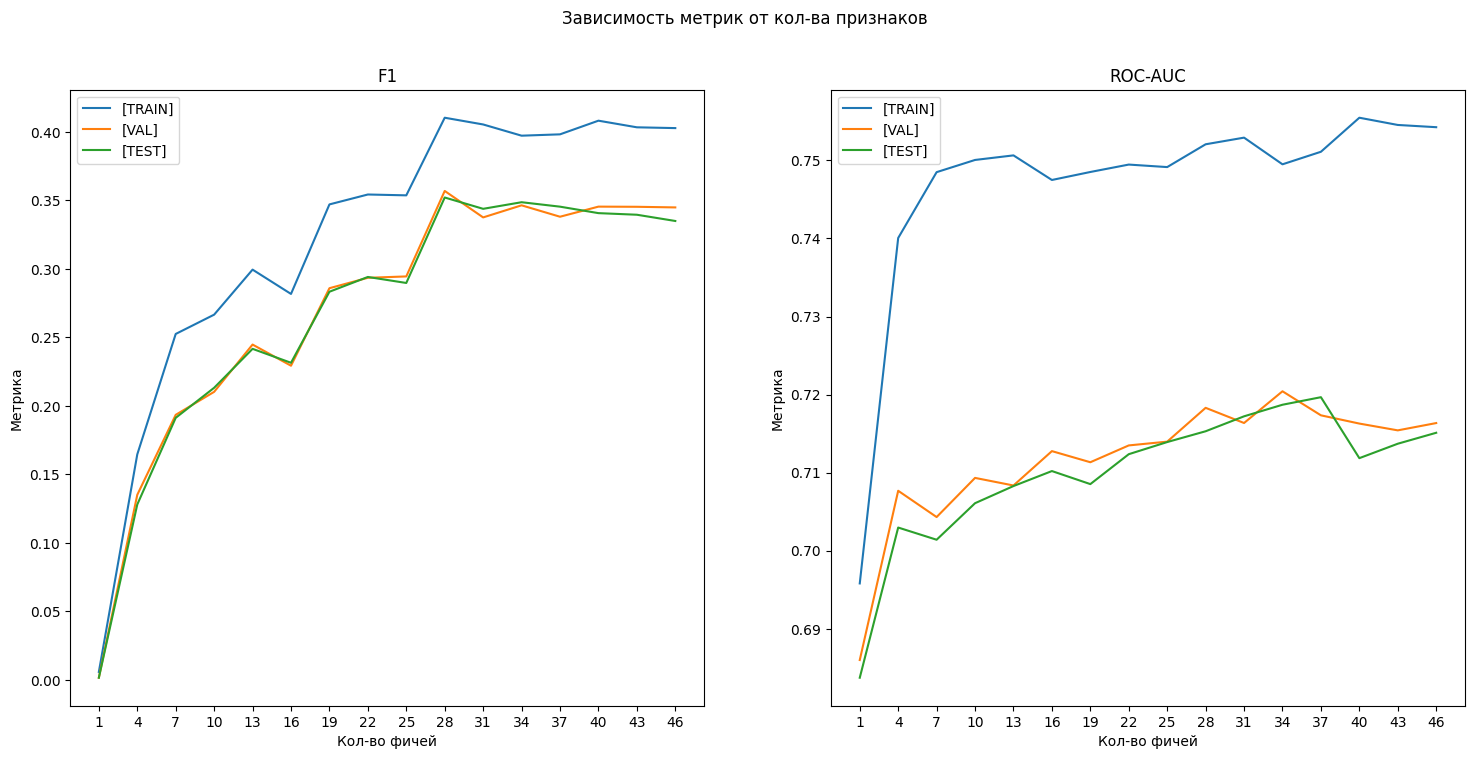

In [417]:
fig, axs = plt.subplots(ncols = 2, figsize = (18, 8), )

fig.suptitle('Зависимость метрик от кол-ва признаков')


plt.title('Метрики от кол-ва фичей')
plt.ylabel('Метрика')
plt.xlabel('Кол-во фичей')


axs[0].plot(train_f1, label = '[TRAIN]')
axs[0].plot(val_f1, label = '[VAL]')
axs[0].plot(test_f1, label = '[TEST]')

axs[0].set_title('F1')
axs[0].set_xticks(ticks = list(range(len(train_f1))), labels = xticks)
axs[0].set_xlabel('Кол-во фичей')
axs[0].set_ylabel('Метрика')




axs[1].plot(train_roc_auc, label = '[TRAIN]')
axs[1].plot(val_roc_auc, label = '[VAL]')
axs[1].plot(test_roc_auc, label = '[TEST]')

axs[1].set_title('ROC-AUC')
axs[1].set_xlabel('Кол-во фичей')
axs[1].set_ylabel('Метрика')

axs[1].set_xticks(ticks = list(range(len(train_f1))), labels = xticks)

axs[0].legend()

axs[1].legend();

In [418]:
num_features = 28
final_features = importances[:num_features]

In [419]:
final_features

['crd_tot_act_qty_sum_6m',
 'crd_cc_clsd_qty_sum_3m',
 'srv_pmt_budg_qty_sum_12m',
 'crd_dc_open_qty_sum_9m',
 'crd_otf_total_qty_sum_12m',
 'dep_inf_new_acct_qty_sum_12m',
 'crd_dc_act_spend_qty_sum_12m',
 'crd_otf_total_qty_12m',
 'crd_cc_clsd_qty',
 'dep_inf_new_acct_qty_sum_6m',
 'srv_mb_econ_qty_sum_6m',
 'crd_cc_mnth_snc_issue_qty_sum_3m',
 'crd_txn_snpd_pos_ever_qty',
 'crd_cc_issued_qty_sum_6m',
 'crd_txn_snpd_pos_ever_qty_sum_3m',
 'crd_cc_open_qty_sum_6m',
 'crd_otf_total_rub_amt_sum_12m',
 'crd_dc_active_open_qty',
 'crd_tot_act_qty',
 'crd_dc_pos_beuaty_qty_sum_3m',
 'srv_mb_econ_qty_sum_3_6',
 'srv_sbol_mnth_1st_txn_qty',
 'crd_dc_pos_beuaty_qty_sum_3_6',
 'crd_tot_act_spend_qty',
 'crd_dc_act_qty',
 'dep_mnth_social_min_qty_sum_3m',
 'seg_crm_day_qty',
 'crd_dc_act_qty_sum_3_6']

In [420]:
tech_cols = ['target']

In [421]:
final_features = ['crd_tot_act_qty_sum_6m',
 'crd_cc_clsd_qty_sum_3m',
 'srv_pmt_budg_qty_sum_12m',
 'crd_dc_open_qty_sum_9m',
 'crd_otf_total_qty_sum_12m',
 'dep_inf_new_acct_qty_sum_12m',
 'crd_dc_act_spend_qty_sum_12m',
 'crd_otf_total_qty_12m',
 'crd_cc_clsd_qty',
 'dep_inf_new_acct_qty_sum_6m',
 'srv_mb_econ_qty_sum_6m',
 'crd_cc_mnth_snc_issue_qty_sum_3m',
 'crd_txn_snpd_pos_ever_qty',
 'crd_cc_issued_qty_sum_6m',
 'crd_txn_snpd_pos_ever_qty_sum_3m',
 'crd_cc_open_qty_sum_6m',
 'crd_otf_total_rub_amt_sum_12m',
 'crd_dc_active_open_qty',
 'crd_tot_act_qty',
 'crd_dc_pos_beuaty_qty_sum_3m',
 'srv_mb_econ_qty_sum_3_6',
 'srv_sbol_mnth_1st_txn_qty',
 'crd_dc_pos_beuaty_qty_sum_3_6',
 'crd_tot_act_spend_qty',
 'crd_dc_act_qty',
 'dep_mnth_social_min_qty_sum_3m',
 'seg_crm_day_qty',
 'crd_dc_act_qty_sum_3_6']

# Last

In [422]:
train_last = train[final_features+tech_cols]
val_last = val[final_features+tech_cols]
test_last = test[final_features+tech_cols]

In [423]:
text_columns = train_last.drop(columns='target').select_dtypes(include=['object']).columns.tolist()

In [424]:
model = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=3, cat_features=text_columns, random_seed=0)
model.fit(train_last.drop(columns='target'), train_last['target'], eval_set = (val_last.drop(columns='target'), val_last['target']), verbose=100, plot=True, early_stopping_rounds = 100)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6632135	test: 0.6634059	best: 0.6634059 (0)	total: 6.17ms	remaining: 6.16s
100:	learn: 0.5104705	test: 0.5141484	best: 0.5141425 (99)	total: 470ms	remaining: 4.18s
200:	learn: 0.5007800	test: 0.5060520	best: 0.5060520 (200)	total: 952ms	remaining: 3.79s
300:	learn: 0.4962226	test: 0.5040737	best: 0.5039715 (287)	total: 1.45s	remaining: 3.38s
400:	learn: 0.4932407	test: 0.5036346	best: 0.5033270 (350)	total: 1.95s	remaining: 2.91s
500:	learn: 0.4906964	test: 0.5035136	best: 0.5031062 (444)	total: 2.43s	remaining: 2.42s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5031061631
bestIteration = 444

Shrink model to first 445 iterations.


In [425]:
# 25
print(f"TRAIN : {roc_auc_score(train_last['target'], model.predict_proba(train_last.drop(columns='target'))[:, 1])}")
print(f"VAL : {roc_auc_score(val_last['target'], model.predict_proba(val_last.drop(columns='target'))[:, 1])}")
print(f"TEST : {roc_auc_score(test_last['target'], model.predict_proba(test_last.drop(columns='target'))[:, 1])}")

TRAIN : 0.752893237014005
VAL : 0.7178796653455256
TEST : 0.7145742525630793


In [426]:
# 25
print(f"TRAIN : {f1_score(train_last['target'], model.predict(train_last.drop(columns='target')))}")
print(f"VAL : {f1_score(val_last['target'], model.predict(val_last.drop(columns='target')))}")
print(f"TEST : {f1_score(test_last['target'], model.predict(test_last.drop(columns='target')))}")

TRAIN : 0.4191022964509395
VAL : 0.3648556711050637
TEST : 0.3545508625817966


In [428]:
print(classification_report(test_last['target'], model.predict(test_last.drop(columns='target'))))

              precision    recall  f1-score   support

         0.0       0.70      0.82      0.76     12285
         1.0       0.45      0.29      0.35      6086

    accuracy                           0.65     18371
   macro avg       0.57      0.56      0.56     18371
weighted avg       0.62      0.65      0.62     18371



In [429]:
print(confusion_matrix(test_last['target'], model.predict(test_last.drop(columns='target'))))

[[10073  2212]
 [ 4298  1788]]


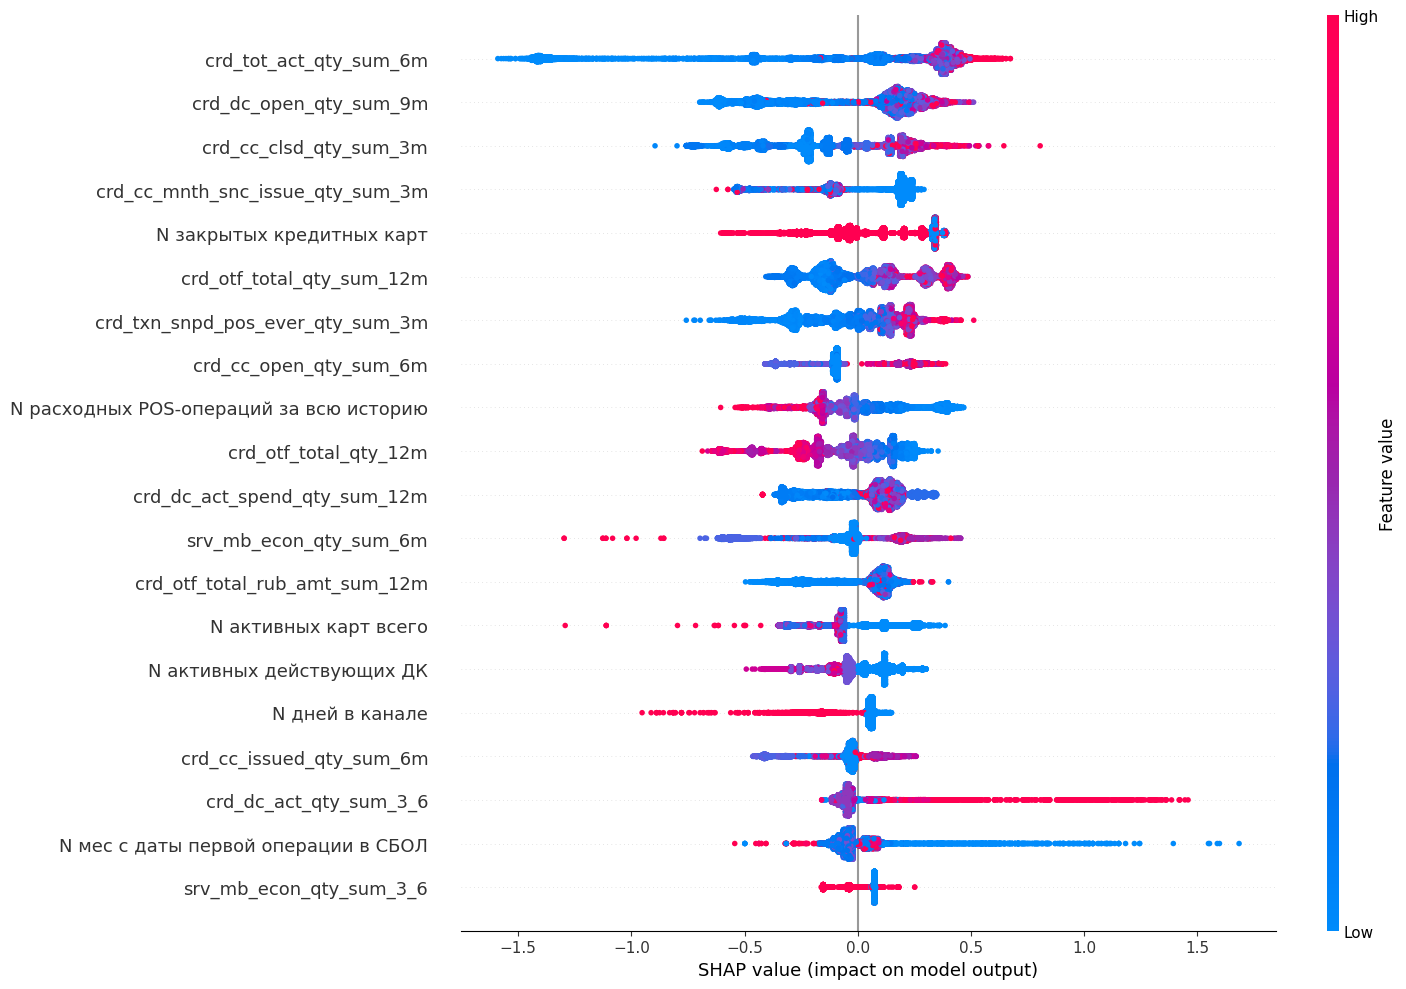

In [430]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(test_last.drop(columns='target'))

shap.summary_plot(shap_values, test_last.drop(columns='target').rename(columns=feature_names), plot_size=(15, 10))

In [431]:
importances = model.get_feature_importance()
feature_names = train_last.drop(columns='target').columns

In [432]:
imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

top10_features = imp_df.head(10)['feature'].tolist()
print(top10_features)

['crd_tot_act_qty_sum_6m', 'crd_cc_clsd_qty_sum_3m', 'crd_cc_clsd_qty', 'crd_dc_open_qty_sum_9m', 'crd_cc_mnth_snc_issue_qty_sum_3m', 'srv_pmt_budg_qty_sum_12m', 'crd_cc_issued_qty_sum_6m', 'crd_dc_act_spend_qty_sum_12m', 'srv_mb_econ_qty_sum_6m', 'crd_otf_total_qty_sum_12m']


In [433]:
train_plot = train_last.copy()

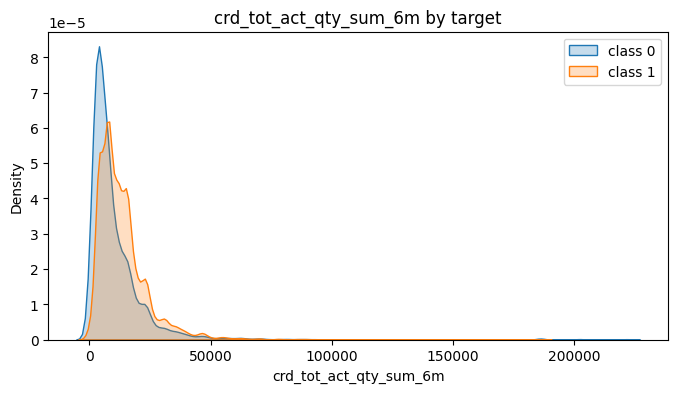

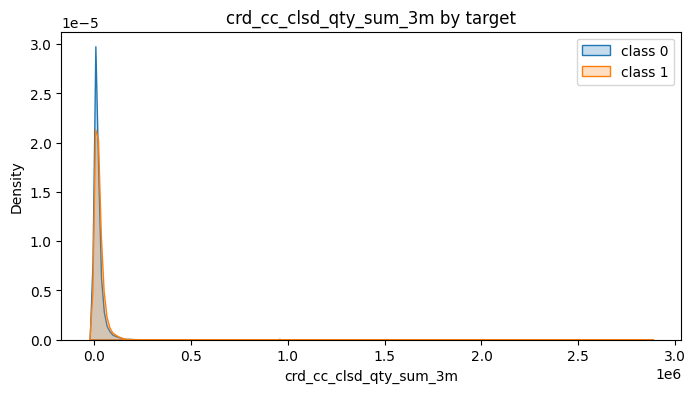

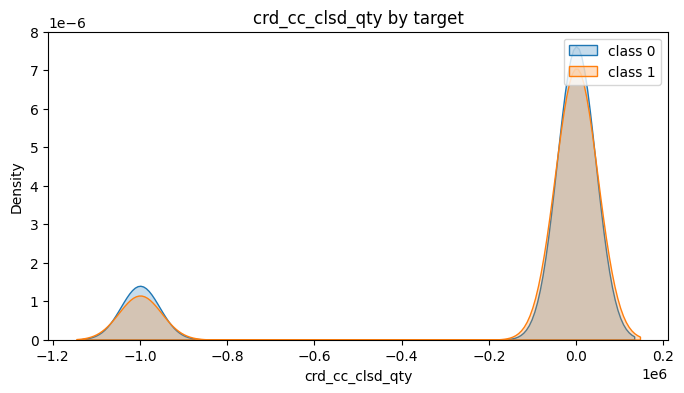

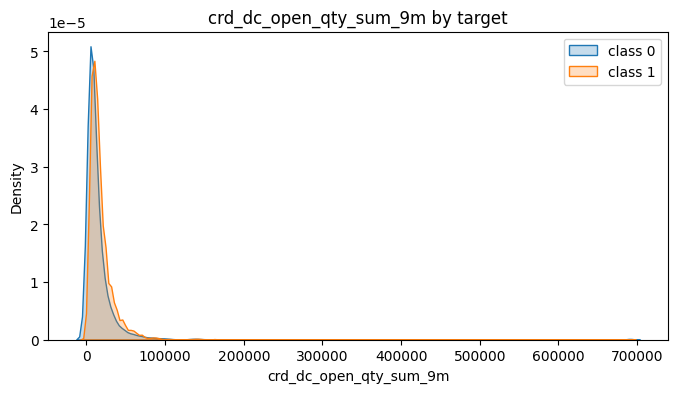

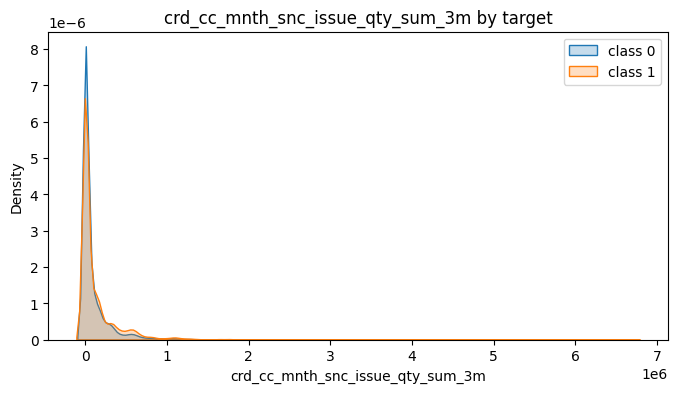

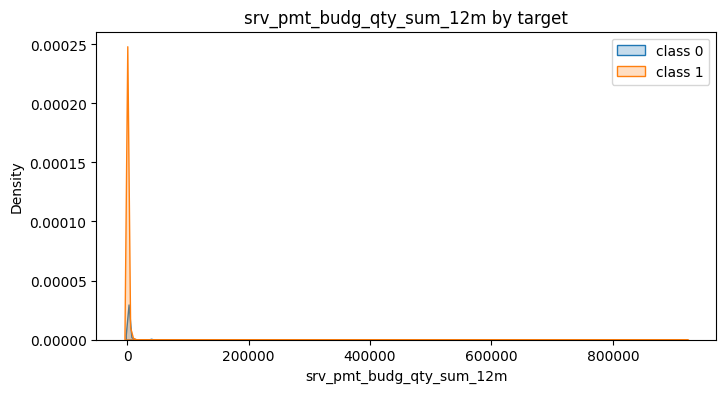

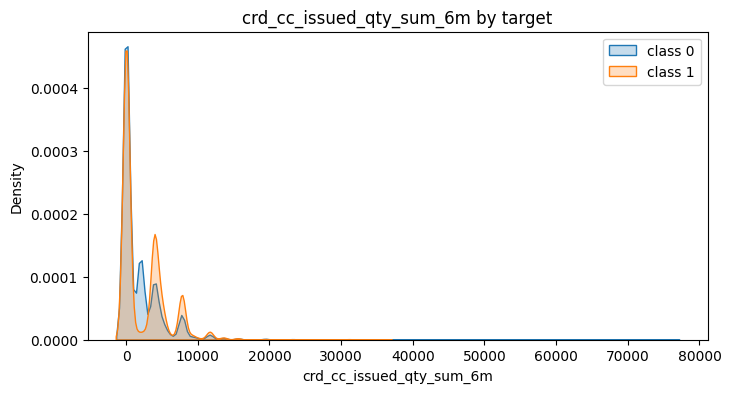

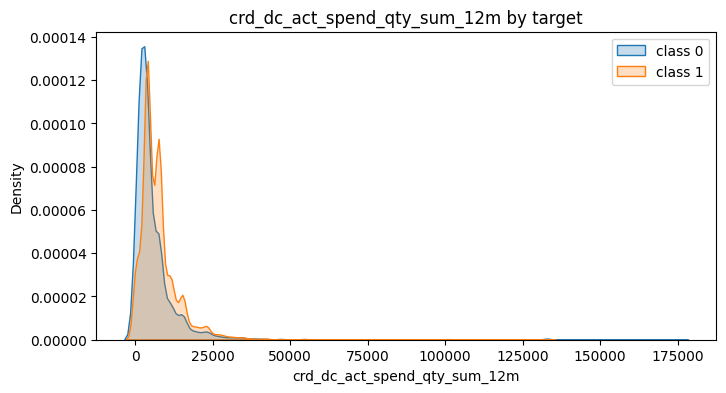

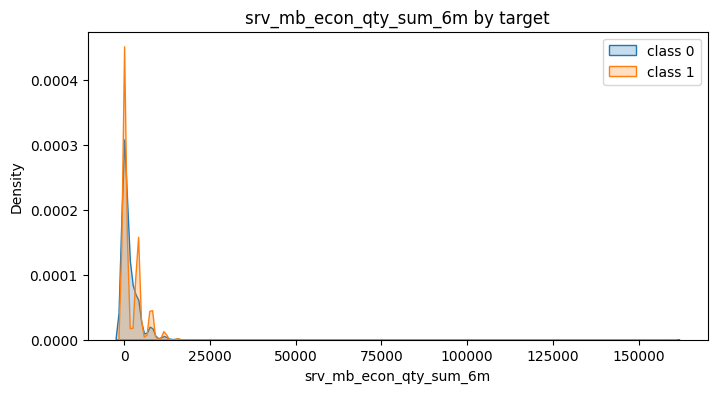

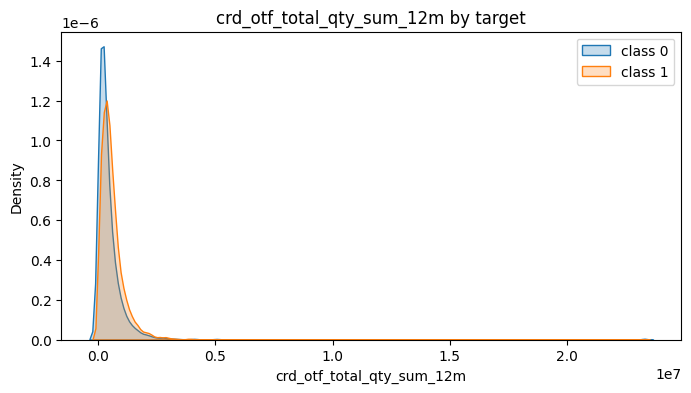

In [434]:
for col in top10_features:
    plt.figure(figsize=(8,4))
    sns.kdeplot(train_plot.loc[train_plot['target'] == 0, col], label='class 0', fill=True)
    sns.kdeplot(train_plot.loc[train_plot['target'] == 1, col], label='class 1', fill=True)
    plt.title(f'{col} by target')
    plt.legend()
    plt.show()

# Optuna

In [437]:
def objective(trial):
    param = {
        "n_estimators": trial.suggest_int('n_estimators', 100, 2000),
        "learning_rate": trial.suggest_float('learning_rate', 0.01, 0.2),
        "objective": trial.suggest_categorical("objective", ["Logloss", "CrossEntropy"]),
        "depth": trial.suggest_int("depth", 3, 10),
        "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-2, 10),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 1.0),
        "min_child_samples": trial.suggest_float("min_child_samples", 100, 1000, step=100),
        "grow_policy": trial.suggest_categorical("grow_policy", ['SymmetricTree', 'Depthwise', 'Lossguide']),
        "border_count": trial.suggest_categorical("border_count", [128, 256, 512, 1024]),
        "auto_class_weights": trial.suggest_categorical("auto_class_weights", [None, 'Balanced', 'SqrtBalanced'])
    }
    
    
    if param['objective'] == 'CrossEntropy':
        param['auto_class_weights'] = None
    
    
    model = CatBoostClassifier(**param, verbose=False, random_seed=0,  cat_features = text_columns)
        
    model.fit(train_last.drop(columns='target'), train_last['target'], eval_set = (val_last.drop(columns='target'), val_last['target']), early_stopping_rounds=50, plot=False)
    
    val_roc_auc = roc_auc_score(val_last['target'], model.predict_proba(val_last.drop(columns='target'))[:, 1])
    
    train_roc_auc = roc_auc_score(train_last['target'], model.predict_proba(train_last.drop(columns='target'))[:, 1])
    
    if train_roc_auc - val_roc_auc > 0.01:
        return 0
    else:
        return val_roc_auc

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=150)

In [439]:
# I can not show parameters, because i am under NDA
model = ctb.CatBoostClassifier(n_estimators=x, depth=x, learning_rate = x, l2_leaf_reg=x, 
                               colsample_bylevel=x, min_child_samples=x, grow_policy='x', border_count=x,
                               auto_class_weights=x,
                               verbose=x,  
                               random_seed=0, early_stopping_rounds=x)
model.fit(train_last.drop(columns='target'), train_last['target'], eval_set = (val_last.drop(columns='target'), val_last['target']), plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6733177	test: 0.6737193	best: 0.6737193 (0)	total: 13.1ms	remaining: 1.79s
100:	learn: 0.5101939	test: 0.5139879	best: 0.5139879 (100)	total: 922ms	remaining: 338ms
137:	learn: 0.5066158	test: 0.5110027	best: 0.5110027 (137)	total: 1.32s	remaining: 0us

bestTest = 0.5110027206
bestIteration = 137



In [440]:
# 25
print(f"TRAIN : {roc_auc_score(train_last['target'], model.predict_proba(train_last.drop(columns='target'))[:, 1])}")
print(f"VAL : {roc_auc_score(val_last['target'], model.predict_proba(val_last.drop(columns='target'))[:, 1])}")
print(f"TEST : {roc_auc_score(test_last['target'], model.predict_proba(test_last.drop(columns='target'))[:, 1])}")

TRAIN : 0.7372701978627393
VAL : 0.7279387853112601
TEST : 0.7250956277081811


In [441]:
# 25
print(f"TRAIN : {f1_score(train_last['target'], model.predict(train_last.drop(columns='target')))}")
print(f"VAL : {f1_score(val_last['target'], model.predict(val_last.drop(columns='target')))}")
print(f"TEST : {f1_score(test_last['target'], model.predict(test_last.drop(columns='target')))}")

TRAIN : 0.35399230144436206
VAL : 0.3374616280300624
TEST : 0.32551635111876076


In [442]:
print(classification_report(test_last['target'], model.predict(test_last.drop(columns='target'))))

              precision    recall  f1-score   support

         0.0       0.70      0.86      0.77     12285
         1.0       0.47      0.25      0.33      6086

    accuracy                           0.66     18371
   macro avg       0.58      0.56      0.55     18371
weighted avg       0.62      0.66      0.62     18371



In [443]:
y_pred = model.predict_proba(test_last.drop(columns=['target']))[:, 1]

In [444]:
percentiles = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

In [445]:
x_oot = test_last.drop(columns=['target'])
y_oot = test_last['target']

In [446]:
results = []
for p in percentiles:
    n_samples = int(len(y_pred) * p)
    
    indices = np.argsort(y_pred)[-n_samples:]
    y_pred_sample = y_pred.copy()
    min_score = min(y_pred_sample[indices])
    y_pred_sample[indices] = 1
    y_pred_sample[y_pred_sample != 1] = 0
    
    
    precision = precision_score(y_oot, y_pred_sample)
    recall = recall_score(y_oot, y_pred_sample)
    f1 = 2 * ((precision*recall)/(precision+recall))
    lift = precision/y_oot.mean()
    
    results.append({
        'Share %': p*100,
        'Subsample': n_samples,
        'Precision': precision,
        'Recall': recall,
        'F1_score':f1,
        'Min_score': min_score,
        'Lift': lift
    })
    # break
    
results_df = pd.DataFrame(results)

In [447]:
results_df

,Share %,Subsample,Precision,Recall,F1_score,Min_score,Lift
0,1.0,183,0.453552,0.013638,0.026480,0.558847,1.369077
1,3.0,551,0.459165,0.041571,0.076239,0.538289,1.386021
2,5.0,918,0.467320,0.070490,0.122501,0.529260,1.410638
3,10.0,1837,0.473054,0.142787,0.219361,0.514904,1.427945
4,20.0,3674,0.473870,0.286066,0.356762,0.496309,1.430410
5,30.0,5511,0.477772,0.432632,0.454083,0.481199,1.442186
6,40.0,7348,0.474823,0.573283,0.519428,0.459510,1.433285
7,50.0,9185,0.476973,0.719849,0.573767,0.427727,1.439776
8,60.0,11022,0.473508,0.857542,0.610124,0.389767,1.429314
9,70.0,12859,0.465433,0.983405,0.631829,0.224743,1.404940


In [448]:
model.save_model('final_model_new.cbm')

In [449]:
train_last.to_parquet('train_last_new.parquet')
val_last.to_parquet('val_last_new.parquet')
test_last.to_parquet('test_last_new.parquet')

In [450]:
y_pred = model.predict_proba(test_last.drop(columns='target'))

In [451]:
test_last['score'] = y_pred[:, 1]

In [453]:
test_f_max = test_last[['target', 'score']]

In [454]:
def max_fbeta_threshold_np(y_true, y_score, beta: float = 1.0):
    order = np.argsort(-y_score)
    y_true = np.asarray(y_true)[order]
    y_score = np.asarray(y_score)[order]
    
    thresholds, idx_first = np.unique(y_score, return_index=True)
    thresholds = thresholds[::-1]
    idx_first = idx_first[::-1]
    
    tp_cum = np.cumsum(y_true)
    fp_cum = np.cumsum(1- y_true)
    
    tp = tp_cum[idx_first]
    fp = fp_cum[idx_first]
    fn = tp_cum[-1] - tp
    
    beta2 = beta**2
    presicion = np.where(tp+fp == 0, 0.0, tp/(tp+fp))
    recall = np.where(fp+fn == 0, 0.0, tp/(tp+fn))
    denom = beta2*presicion + recall
    fbeta = np.where(denom == 0, 0.0, (1+beta2)*(presicion*recall)/denom)
    
    i = int(np.argmax(fbeta))
    return {
        "best fbeta": float(fbeta[i]),
        "best thresholds": float(thresholds[i]),
        "presicion": float(presicion[i]),
        "recall": float(recall[i]),
        "beta": beta
    }

In [455]:
res = max_fbeta_threshold_np(test_f_max['target'].values, test_f_max['score'].values, beta=1.0)

In [456]:
res

{'best fbeta': 0.6318457882228676,
 'best thresholds': 0.22828322244009014,
 'presicion': 0.46556152229745507,
 'recall': 0.9829116003943477,
 'beta': 1.0}